# ⚡ SKU Energy & Profitability Analysis — Bottling Plant

**Statistical analysis of production energy consumption per SKU** for a bottling plant,
built during an ITESM statistical-methods challenge with **Coca-Cola FEMSA (KOF)**,
the world's largest Coca-Cola bottler (team project).

The original work analyzed real plant sensor data — energy drawn by the refrigeration
compressors serving each bottling line, broken down by SKU (brand + flavor + size +
package). This notebook reproduces the methodology with **synthetic data**; SKU names
are generic and no client data is included.

**Pipeline**

1. Synthetic plant data — compressor energy per production interval, per SKU
2. Exploratory analysis of energy by compressor
3. Normality checks (Q–Q) and **95% confidence intervals** for mean energy
4. **Hypothesis testing** — Welch's t-tests (two- and one-tailed) between compressors
5. **ANOVA + Tukey HSD** across compressors and across SKUs
6. **Profitability** — energy cost per box vs. unit margin → which SKU wins?


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.api as sms
from statsmodels.stats.multicomp import MultiComparison

RNG = np.random.default_rng(3)

# --- Chart tokens ---
INK, ACCENT, TEAL, SOFT = "#1E3A5F", "#C2703D", "#4C837C", "#5A5A5A"

def style_ax(ax, title, subtitle=None):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#C9D2DC")
    ax.tick_params(colors=SOFT, labelsize=9)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=INK, pad=30)
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes, fontsize=9.5, color=SOFT)

ALPHA = 0.05
ENERGY_PRICE = 2.5  # MXN per kWh (industrial tariff, illustrative)

## 1. Synthetic plant data

Each production **interval** records the energy (kWh) drawn by every refrigeration
compressor serving the line while one SKU was being bottled, plus the boxes produced.
The structure mirrors the original dataset (SKU = brand + size + package; compressors
`COMP01…COMP09`); values are simulated.

In [2]:
SKUS = {
    #  name                        energy factor, boxes/interval, margin MXN/box
    "Cola 2.5 L PET":              (1.15, 1100, 34),
    "Cola Light 600 mL PET":       (0.75, 1650, 33),
    "Orange Soda 3 L PET":         (1.12, 1200, 28),
    "Pineapple 600 mL PET":        (0.82, 1500, 30),
    "Strawberry 500 mL Glass":     (0.95,  900, 34),
    "Still Water 1 L PET":         (0.70, 1800, 14),
}
# Mean kWh per interval for each compressor (plant baseline)
COMPRESSORS = {"COMP01": 330, "COMP02": 298, "COMP05": 262, "COMP07": 262, "COMP09": 180}
N_INTERVALS = 90
SIGMA = 20

rows = []
for sku, (factor, boxes_base, margin) in SKUS.items():
    for i in range(N_INTERVALS):
        boxes = boxes_base * RNG.normal(1, 0.06)
        for comp, mu in COMPRESSORS.items():
            rows.append({
                "interval": i,
                "sku": sku,
                "compressor": comp,
                "energy_kwh": RNG.normal(mu * factor, SIGMA),
                "boxes": boxes,
            })
data = pd.DataFrame(rows)
margins = pd.Series({sku: v[2] for sku, v in SKUS.items()}, name="margin_mxn_box")

print(f"{data.shape[0]:,} sensor records · {len(SKUS)} SKUs · "
      f"{len(COMPRESSORS)} compressors · {N_INTERVALS} intervals each")
data.head()

2,700 sensor records · 6 SKUs · 5 compressors · 90 intervals each


,interval,sku,compressor,energy_kwh,boxes
0,0,Cola 2.5 L PET,COMP01,328.386699,1234.700662
1,0,Cola 2.5 L PET,COMP02,351.061977,1234.700662
2,0,Cola 2.5 L PET,COMP05,289.944608,1234.700662
3,0,Cola 2.5 L PET,COMP07,292.247014,1234.700662
4,0,Cola 2.5 L PET,COMP09,202.688057,1234.700662


## 2. Energy by compressor — focus SKU

As in the original analysis, we first zoom into one SKU and compare how much energy
each compressor draws while that product runs.

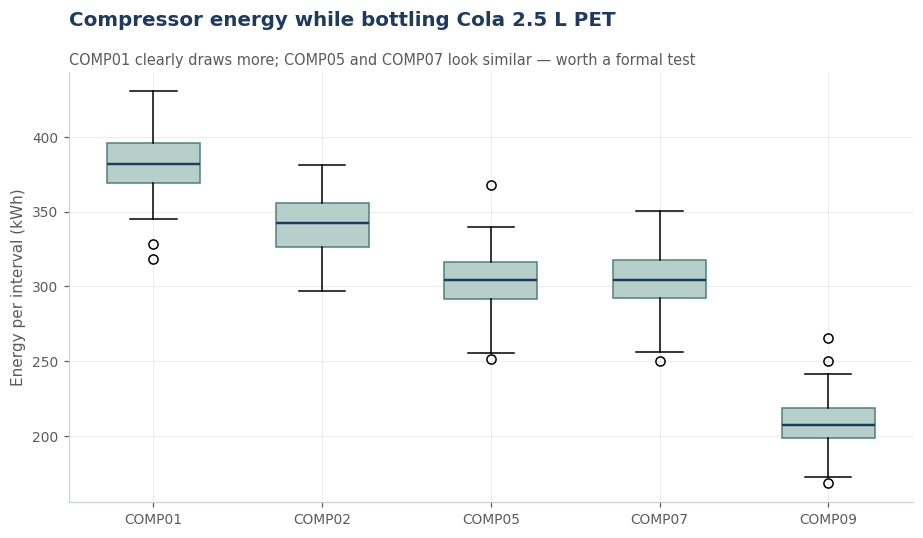

In [3]:
FOCUS = "Cola 2.5 L PET"
focus = data[data.sku == FOCUS]

fig, ax = plt.subplots(figsize=(8.5, 5))
groups = [focus.loc[focus.compressor == c, "energy_kwh"] for c in COMPRESSORS]
bp = ax.boxplot(groups, labels=list(COMPRESSORS), patch_artist=True, widths=0.55,
                medianprops=dict(color=INK, linewidth=1.6))
for patch in bp["boxes"]:
    patch.set_facecolor("#B7CFCB"); patch.set_edgecolor(TEAL)
ax.set_ylabel("Energy per interval (kWh)", color=SOFT)
style_ax(ax, f"Compressor energy while bottling {FOCUS}",
         "COMP01 clearly draws more; COMP05 and COMP07 look similar — worth a formal test")
plt.tight_layout()
plt.show()

## 3. Normality check and confidence intervals

Q–Q plots confirm the energy readings are approximately normal, so t-based inference
is appropriate. We then compute the **95% confidence interval** for each compressor's
mean energy.

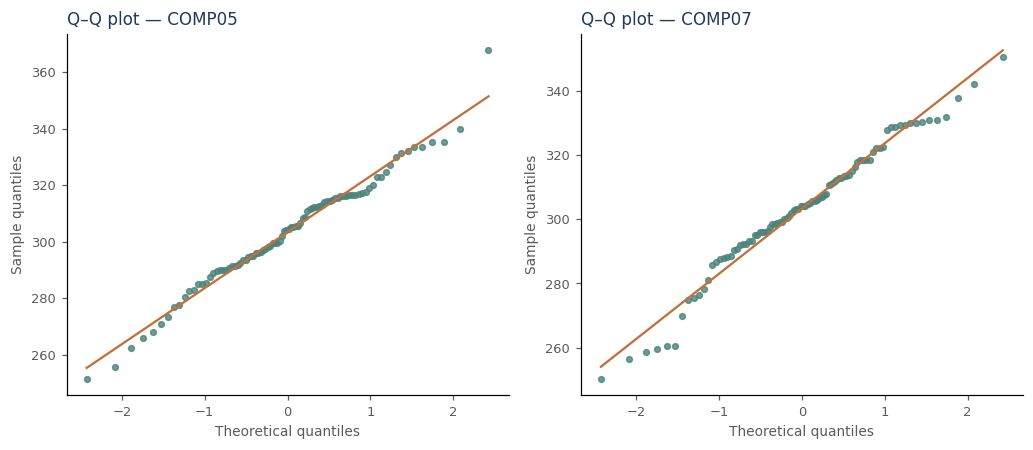

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
for ax, comp in zip(axes, ["COMP05", "COMP07"]):
    sample = focus.loc[focus.compressor == comp, "energy_kwh"]
    (osm, osr), (slope, intercept, r) = stats.probplot(sample)
    ax.scatter(osm, osr, s=14, color=TEAL, alpha=0.8)
    ax.plot(osm, slope * osm + intercept, color=ACCENT, lw=1.5)
    ax.set_title(f"Q–Q plot — {comp}", fontsize=11, color=INK, loc="left")
    ax.set_xlabel("Theoretical quantiles", color=SOFT, fontsize=9)
    ax.set_ylabel("Sample quantiles", color=SOFT, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=SOFT, labelsize=8.5)
plt.tight_layout()
plt.show()

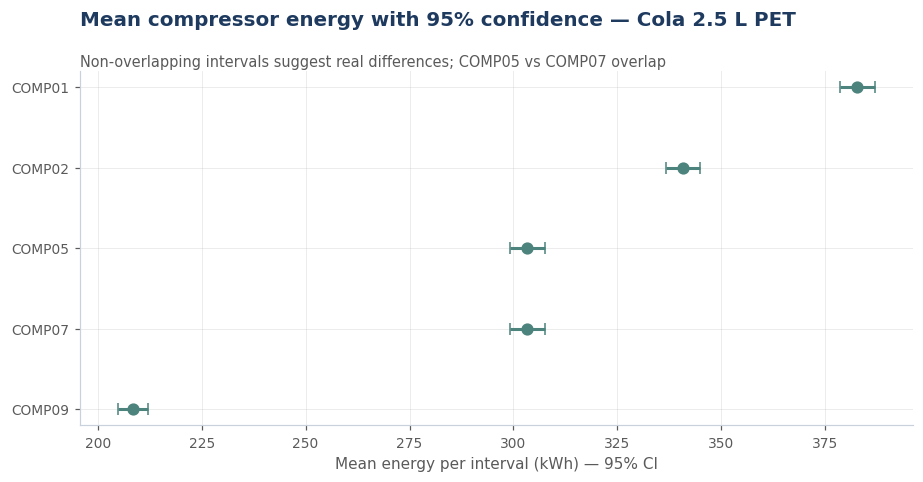

,compressor,mean,ci_low,ci_high
0,COMP01,382.8,378.5,387.0
1,COMP02,340.8,336.7,344.8
2,COMP05,303.4,299.2,307.5
3,COMP07,303.3,299.1,307.6
4,COMP09,208.5,204.8,212.2


In [5]:
ci_rows = []
for comp in COMPRESSORS:
    sample = focus.loc[focus.compressor == comp, "energy_kwh"]
    lo, hi = sms.DescrStatsW(sample).tconfint_mean(ALPHA)
    ci_rows.append({"compressor": comp, "mean": sample.mean(), "ci_low": lo, "ci_high": hi})
ci = pd.DataFrame(ci_rows)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.errorbar(ci["mean"], ci.compressor, xerr=[ci["mean"] - ci.ci_low, ci.ci_high - ci["mean"]],
            fmt="o", color=TEAL, ecolor=TEAL, elinewidth=2, capsize=4, markersize=7)
ax.set_xlabel("Mean energy per interval (kWh) — 95% CI", color=SOFT)
ax.invert_yaxis()
style_ax(ax, f"Mean compressor energy with 95% confidence — {FOCUS}",
         "Non-overlapping intervals suggest real differences; COMP05 vs COMP07 overlap")
plt.tight_layout()
plt.show()
ci.round(1)

## 4. Hypothesis testing — Welch's t-test

**Is the difference between two compressors statistically significant?**

| | Two-tailed | One-tailed |
|---|---|---|
| H₀ | μ₁ − μ₂ = 0 | μ₁ − μ₂ ≤ 0 |
| H₁ | μ₁ − μ₂ ≠ 0 | μ₁ − μ₂ > 0 |

We run the contrast the original team ran twice: a pair that *looks* different
(COMP01 vs COMP02) and a pair that looks similar (COMP05 vs COMP07).

In [6]:
def welch_report(comp_a, comp_b):
    a = focus.loc[focus.compressor == comp_a, "energy_kwh"]
    b = focus.loc[focus.compressor == comp_b, "energy_kwh"]
    cm = sms.CompareMeans(sms.DescrStatsW(a), sms.DescrStatsW(b))
    t2, p2, dof = cm.ttest_ind(alternative="two-sided", usevar="unequal")
    t1, p1, _ = cm.ttest_ind(alternative="larger", usevar="unequal")
    verdict = "REJECT H0 — significant difference" if p2 < ALPHA else "FAIL TO REJECT H0 — no evidence of difference"
    print(f"{comp_a} vs {comp_b}:  Δmean = {a.mean() - b.mean():+7.1f} kWh · "
          f"t = {t2:6.2f} · p(two-tailed) = {p2:.2e} · p(one-tailed) = {p1:.2e}")
    print(f"   → {verdict} (α = {ALPHA})\n")
    return t2, dof

t_sig, dof_sig = welch_report("COMP01", "COMP02")
t_ns, dof_ns = welch_report("COMP05", "COMP07")

COMP01 vs COMP02:  Δmean =   +42.0 kWh · t =  14.14 · p(two-tailed) = 6.69e-31 · p(one-tailed) = 3.34e-31
   → REJECT H0 — significant difference (α = 0.05)

COMP05 vs COMP07:  Δmean =    +0.0 kWh · t =   0.02 · p(two-tailed) = 9.87e-01 · p(one-tailed) = 4.94e-01
   → FAIL TO REJECT H0 — no evidence of difference (α = 0.05)



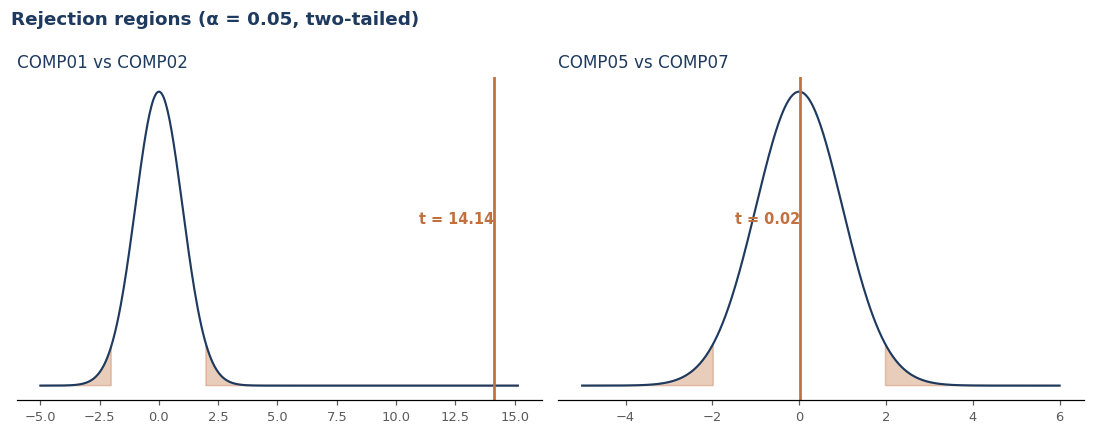

In [7]:
# Visualizing both tests on the t distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (t_obs, dof, label) in zip(axes, [(t_sig, dof_sig, "COMP01 vs COMP02"),
                                          (t_ns, dof_ns, "COMP05 vs COMP07")]):
    x = np.linspace(-5, max(6, abs(t_obs) + 1), 500)
    y = stats.t(dof).pdf(x)
    t_crit = stats.t(dof).ppf(1 - ALPHA / 2)
    ax.plot(x, y, color=INK, lw=1.4)
    ax.fill_between(x, y, where=(np.abs(x) >= t_crit), color=ACCENT, alpha=0.35)
    ax.axvline(t_obs, color=ACCENT, lw=1.8)
    ax.annotate(f"t = {t_obs:.2f}", (t_obs, stats.t(dof).pdf(0) * 0.55),
                color=ACCENT, fontsize=9.5, fontweight="bold",
                ha="left" if t_obs < 0 else "right")
    ax.set_title(label, fontsize=11, color=INK, loc="left")
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(colors=SOFT, labelsize=8.5)
fig.suptitle("Rejection regions (α = 0.05, two-tailed)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

## 5. ANOVA + Tukey HSD

Pairwise t-tests inflate the false-positive rate, so — as in the original analysis —
we run a one-way **ANOVA** across all compressors and follow up with **Tukey's HSD**
to see exactly which pairs differ.

In [8]:
samples = [focus.loc[focus.compressor == c, "energy_kwh"].to_numpy() for c in COMPRESSORS]
f_stat, p_anova = stats.f_oneway(*samples)
print(f"ANOVA across compressors ({FOCUS}): F = {f_stat:.1f}, p = {p_anova:.2e}\n")

mc = MultiComparison(focus.energy_kwh.to_numpy(), focus.compressor.to_numpy())
print(mc.tukeyhsd())

ANOVA across compressors (Cola 2.5 L PET): F = 980.7, p = 3.99e-219

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
COMP01 COMP02  -41.9985   0.0  -49.9694  -34.0276   True
COMP01 COMP05  -79.3791   0.0    -87.35  -71.4082   True
COMP01 COMP07  -79.4265   0.0  -87.3974  -71.4556   True
COMP01 COMP09 -174.2917   0.0 -182.2626 -166.3208   True
COMP02 COMP05  -37.3806   0.0  -45.3515  -29.4097   True
COMP02 COMP07   -37.428   0.0  -45.3989  -29.4571   True
COMP02 COMP09 -132.2933   0.0 -140.2642 -124.3224   True
COMP05 COMP07   -0.0474   1.0   -8.0183    7.9235  False
COMP05 COMP09  -94.9126   0.0 -102.8835  -86.9417   True
COMP07 COMP09  -94.8653   0.0 -102.8362  -86.8944   True
--------------------------------------------------------


## 6. Energy across SKUs

Same machinery, different question: on the compressor shared by every line
(**COMP05**), does the product being bottled change the energy draw?

Tukey HSD across SKUs: 15 of 15 pairwise differences are significant


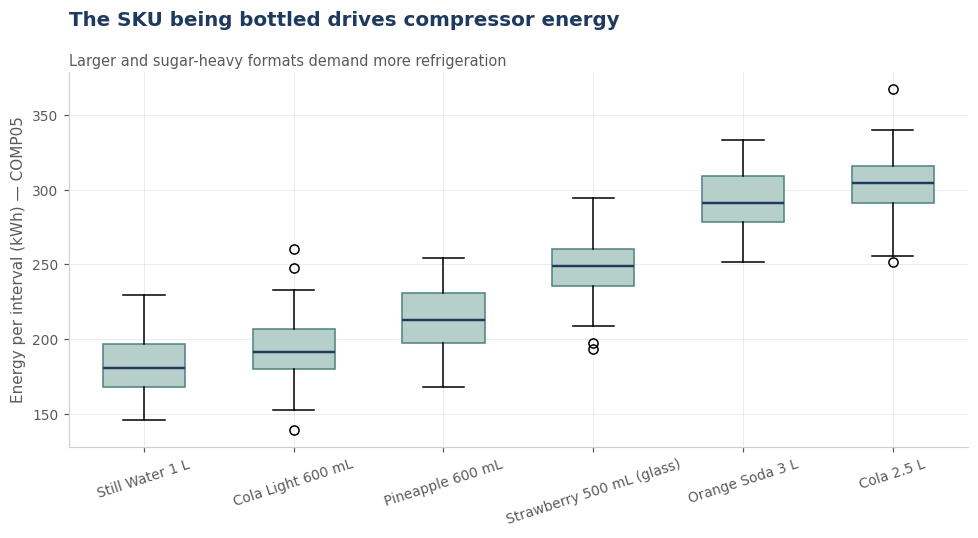

In [9]:
shared = data[data.compressor == "COMP05"]
order = shared.groupby("sku").energy_kwh.mean().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5))
groups = [shared.loc[shared.sku == s, "energy_kwh"] for s in order]
bp = ax.boxplot(groups, labels=[s.replace(" PET", "").replace(" Glass", " (glass)") for s in order],
                patch_artist=True, widths=0.55, medianprops=dict(color=INK, linewidth=1.6))
for patch in bp["boxes"]:
    patch.set_facecolor("#B7CFCB"); patch.set_edgecolor(TEAL)
ax.tick_params(axis="x", rotation=18)
ax.set_ylabel("Energy per interval (kWh) — COMP05", color=SOFT)
style_ax(ax, "The SKU being bottled drives compressor energy",
         "Larger and sugar-heavy formats demand more refrigeration")
plt.tight_layout()
plt.show()

mc_sku = MultiComparison(shared.energy_kwh.to_numpy(), shared.sku.to_numpy())
tukey = mc_sku.tukeyhsd()
sig_pairs = int(tukey.reject.sum())
print(f"Tukey HSD across SKUs: {sig_pairs} of {len(tukey.reject)} pairwise differences are significant")

## 7. Profitability — netting energy cost out of the margin

The commercial question behind the analysis: **which SKU makes the most money once
its production energy is paid for?** We aggregate each SKU's energy per box, price it
at the industrial tariff, and subtract it from the unit margin.

In [10]:
per_interval = (data.groupby(["sku", "interval"])
                    .agg(energy_kwh=("energy_kwh", "sum"), boxes=("boxes", "first"))
                    .reset_index())
profit = (per_interval.groupby("sku")
          .apply(lambda g: pd.Series({
              "kwh_per_box": g.energy_kwh.sum() / g.boxes.sum(),
          }), include_groups=False))
profit["energy_cost_box"] = profit.kwh_per_box * ENERGY_PRICE
profit["margin_mxn_box"] = margins
profit["net_margin_box"] = profit.margin_mxn_box - profit.energy_cost_box
profit = profit.sort_values("net_margin_box", ascending=False)

winner = profit.index[0]
most_efficient = profit.kwh_per_box.idxmin()
print(f"Most energy-efficient SKU: {most_efficient} ({profit.kwh_per_box.min():.2f} kWh/box)")
print(f"Highest net margin after energy: {winner} (${profit.net_margin_box.iloc[0]:.2f} MXN/box)")
profit.round(2)

Most energy-efficient SKU: Still Water 1 L PET (0.51 kWh/box)
Highest net margin after energy: Cola Light 600 mL PET ($31.49 MXN/box)


,kwh_per_box,energy_cost_box,margin_mxn_box,net_margin_box
sku,,,,
Cola Light 600 mL PET,0.61,1.51,33,31.49
Cola 2.5 L PET,1.40,3.49,34,30.51
Strawberry 500 mL Glass,1.41,3.52,34,30.48
Pineapple 600 mL PET,0.72,1.81,30,28.19
Orange Soda 3 L PET,1.23,3.08,28,24.92
Still Water 1 L PET,0.51,1.29,14,12.71


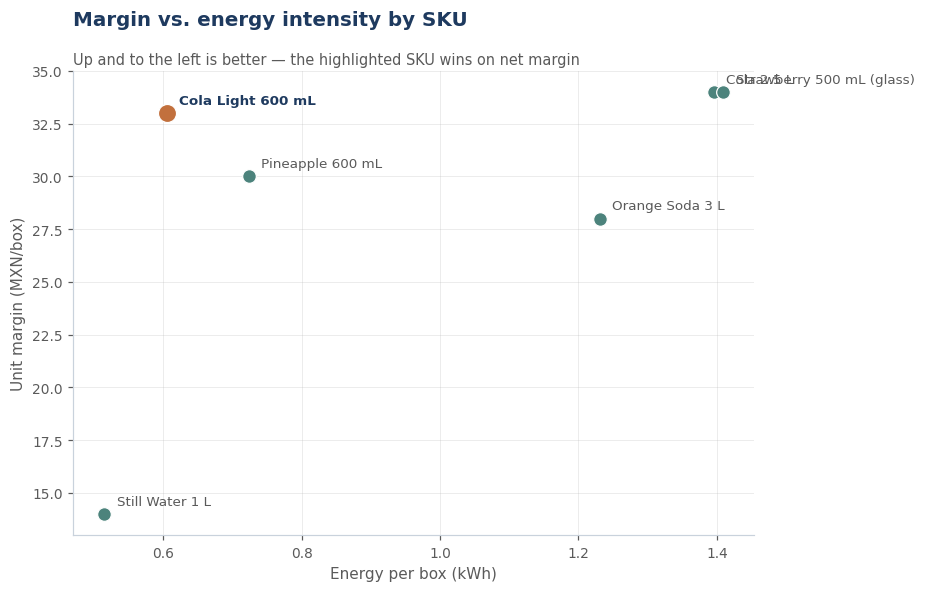

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sizes = 60
for sku, row in profit.iterrows():
    is_winner = sku == winner
    ax.scatter(row.kwh_per_box, row.margin_mxn_box,
               s=140 if is_winner else 80,
               color=ACCENT if is_winner else TEAL,
               edgecolors="white", linewidths=0.8, zorder=3)
    ax.annotate(sku.replace(" PET", "").replace(" Glass", " (glass)"),
                (row.kwh_per_box, row.margin_mxn_box),
                xytext=(8, 6), textcoords="offset points", fontsize=8.8,
                color=INK if is_winner else SOFT,
                fontweight="bold" if is_winner else "normal")
ax.set_xlabel("Energy per box (kWh)", color=SOFT)
ax.set_ylabel("Unit margin (MXN/box)", color=SOFT)
style_ax(ax, "Margin vs. energy intensity by SKU",
         "Up and to the left is better — the highlighted SKU wins on net margin")
plt.tight_layout()
plt.show()

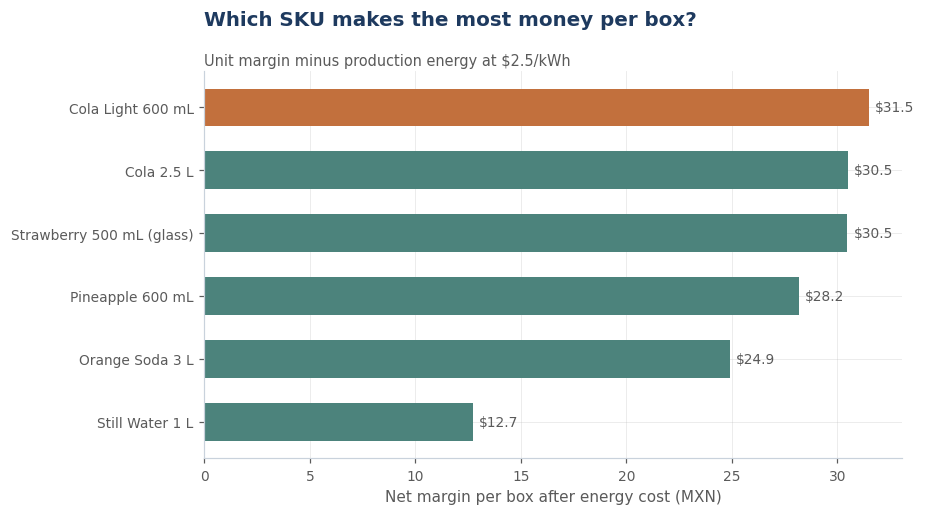

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
labels = [s.replace(" PET", "").replace(" Glass", " (glass)") for s in profit.index]
colors = [ACCENT if s == winner else TEAL for s in profit.index]
bars = ax.barh(labels, profit.net_margin_box, color=colors, height=0.6)
ax.bar_label(bars, fmt="$%.1f", padding=4, fontsize=9, color=SOFT)
ax.invert_yaxis()
ax.set_xlabel("Net margin per box after energy cost (MXN)", color=SOFT)
style_ax(ax, "Which SKU makes the most money per box?",
         f"Unit margin minus production energy at ${ENERGY_PRICE}/kWh")
plt.tight_layout()
fig.savefig("docs/sku_profitability.png", dpi=130, bbox_inches="tight")
plt.show()

## Conclusions

- Compressor energy is **approximately normal** per SKU–compressor group, so t-based
  inference is sound; ANOVA + Tukey HSD identify exactly which compressors differ —
  the visual impression from boxplots is confirmed (or debunked) formally.
- **The SKU being bottled significantly changes energy draw**: larger, sugar-heavy
  formats demand more refrigeration than light and still products.
- Ranking SKUs by **net margin after energy cost** changes the commercial picture:
  the most energy-efficient carbonated SKU climbs to the top, while high-margin but
  energy-hungry formats give part of their margin back to the power bill.
- **Next steps**: extend the cost model beyond refrigeration (filling, packaging),
  use hourly tariffs instead of a flat rate, and schedule energy-intensive SKUs
  in off-peak windows.

---
**Rodrigo Trejo** — Data Scientist & Analytics Engineer ·
[Portfolio](https://rodrigo-trejo-hdz.github.io/) ·
[LinkedIn](https://www.linkedin.com/in/rodrigo-trejo-hdz/)